# Gradient Boosting: A Comprehensive Guide

## 1. Introduction

This notebook covers the step-by-step implementation of **Gradient Boosting** in Python.

### Concept Overview
An ensemble boosting method that builds trees sequentially to predict the residual errors (gradients of loss function) of prior trees.

### Mathematical Formula
The core mathematical relationship or objective is defined as:
$$
F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \gamma_m h_m(\mathbf{x}) \quad \text{where } h_m \text{ fits the pseudo-residuals } r_{im} = -\left[ \frac{\partial L(y_i, F(\mathbf{x}_i))}{\partial F(\mathbf{x}_i)} \right]_{F(\mathbf{x}) = F_{m-1}(\mathbf{x})}
$$

### Real-World Analogy
**Analogy:** Playing golf: first stroke gets you close, second stroke corrects the remaining distance (error), and third corrects the residual.

### Worked Example
**Worked Example:** Predicting if house is expensive. First tree predicts average class probability (0.50). Error is y - 0.50. The next tree is trained to predict this error. Summing predictions corrects the classification boundary.

## 2. Import Libraries

We import the standard data science and machine learning libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn import metrics
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Create Synthetic Dataset

We generate a realistic synthetic dataset to demonstrate the model's behavior and save it locally.

In [2]:
# Programmatic generation of house listings data
from sklearn.datasets import make_classification
np.random.seed(42)
X_raw, y_raw = make_classification(n_samples=500, n_features=4, n_informative=3,
                                  n_redundant=1, n_classes=2, weights=[0.6, 0.4],
                                  class_sep=1.2, random_state=42)
df = pd.DataFrame({
    'SqFt': np.round(X_raw[:, 0] * 500 + 2000, 0),
    'RoomsCount': np.round(np.clip(X_raw[:, 1] * 1.5 + 4, 2, 8), 0).astype(int),
    'Age': np.round(np.clip(X_raw[:, 2] * 15 + 30, 0, 100), 0).astype(int),
    'Income': np.round(np.clip(X_raw[:, 3] * 20000 + 80000, 20000, 200000), -2),
    'Expensive': y_raw
})
df.to_csv('dataset.csv', index=False)

## 4. Load & Inspect Dataset

We load the dataset using pandas to inspect the shape, variables, and summary statistics.

In [3]:
df = pd.read_csv('dataset.csv')
print('Dataset Shape:', df.shape)
df.info()
print(df.describe())

Dataset Shape: (500, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SqFt        500 non-null    float64
 1   RoomsCount  500 non-null    int64  
 2   Age         500 non-null    int64  
 3   Income      500 non-null    float64
 4   Expensive   500 non-null    int64  
dtypes: float64(2), int64(3)
memory usage: 19.7 KB
              SqFt  RoomsCount        Age         Income   Expensive
count   500.000000  500.000000  500.00000     500.000000  500.000000
mean   1679.824000    4.776000   27.78000   89147.600000    0.404000
std     632.945167    1.658712   20.74706   32229.310125    0.491189
min      95.000000    2.000000    0.00000   20000.000000    0.000000
25%    1252.750000    4.000000   11.75000   64500.000000    0.000000
50%    1638.500000    5.000000   22.00000   93800.000000    0.000000
75%    2072.000000    6.000000   44.00000  111125.0

## 5. Data Cleaning

Audit for missing values and duplicates.

In [4]:
print('Null values:\n', df.isnull().sum())
print('Duplicate count:', df.duplicated().sum())

Null values:
 SqFt          0
RoomsCount    0
Age           0
Income        0
Expensive     0
dtype: int64
Duplicate count: 0


## 6. Exploratory Data Analysis (EDA)

We perform visual analysis of the dataset, examining correlation heatmaps and target-colored feature distributions to understand the underlying boundaries.

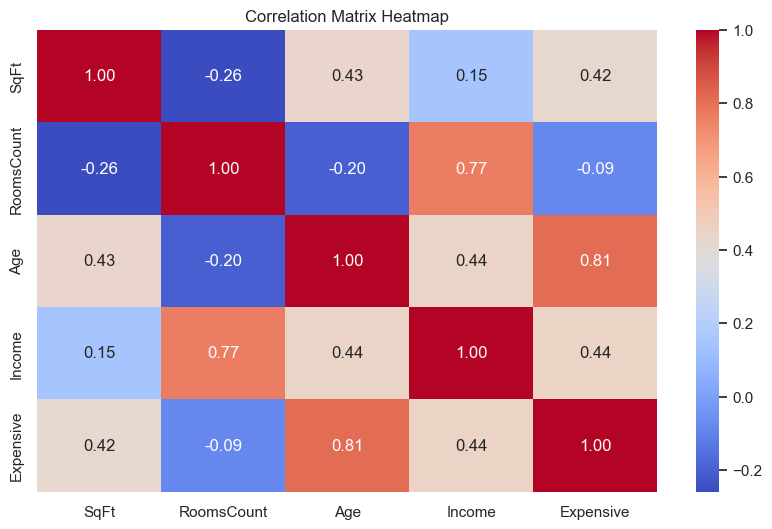

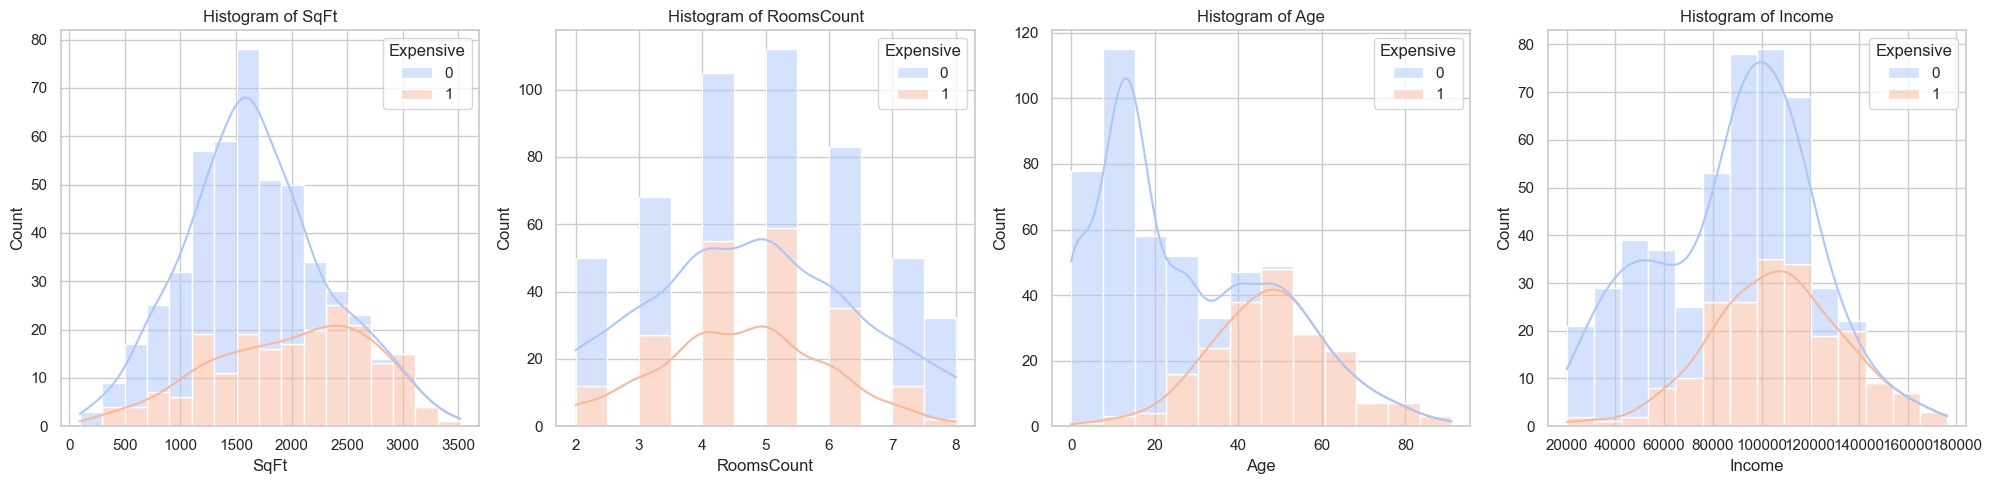

G:\Temp\ipykernel_10600\1348028533.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, ax=axes[1], palette='Set2')


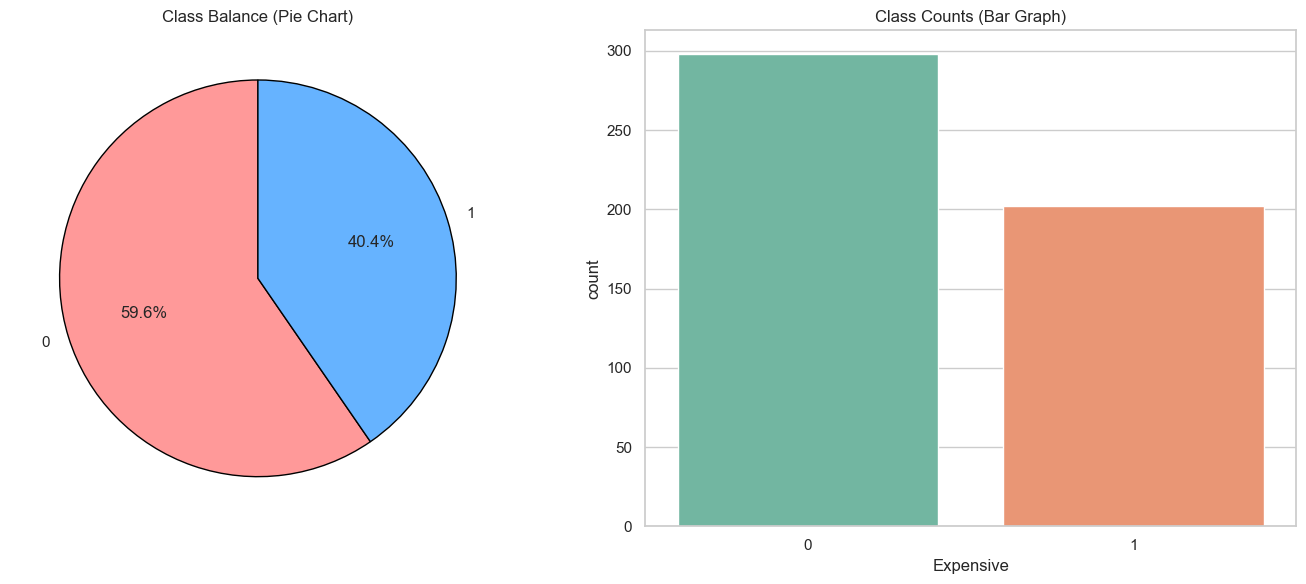

In [5]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

# 1. Feature Histograms (Continuous distributions colored by class)
X_cols = df.columns[:-1]
target_col = df.columns[-1]
fig, axes = plt.subplots(1, len(X_cols), figsize=(5 * len(X_cols), 5))
if len(X_cols) == 1:
    sns.histplot(data=df, x=X_cols[0], hue=target_col, kde=True, ax=axes, multiple='stack', palette='coolwarm')
    axes.set_title(f'Histogram of {X_cols[0]}')
else:
    for idx, col in enumerate(X_cols):
        sns.histplot(data=df, x=col, hue=target_col, kde=True, ax=axes[idx], multiple='stack', palette='coolwarm')
        axes[idx].set_title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

# 2. Class Balance Pie Chart and Bar Graph
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Pie chart
class_counts = df[target_col].value_counts()
axes[0].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff', '#99ff99'], startangle=90, wedgeprops={'edgecolor': 'black'})
axes[0].set_title('Class Balance (Pie Chart)')
# Bar chart
sns.countplot(data=df, x=target_col, ax=axes[1], palette='Set2')
axes[1].set_title('Class Counts (Bar Graph)')
plt.tight_layout()
plt.show()

## 7. Feature Engineering & Scaling

Prepare the features and apply standardization if required.

In [6]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
print('Scaling not strictly needed for this model.')

Scaling not strictly needed for this model.


## 8. Train-Test Split

Divide training and testing sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (350, 4), Test size: (150, 4)


## 9. Model Building

Instantiate and fit the model estimator.

In [8]:
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)
print("Gradient Boosting model trained.")

Gradient Boosting model trained.

## 10. Prediction & 11. Model Evaluation

Check metrics to evaluate model performance.

In [9]:
y_pred = model.predict(X_test)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("F1-Score:", metrics.f1_score(y_test, y_pred))

Accuracy: 0.9733333333333334
F1-Score: 0.9661016949152542


## 12. Visualizing Fit & Boundaries

Generate plots showing classification decision zones, regression lines, or clustering segments.

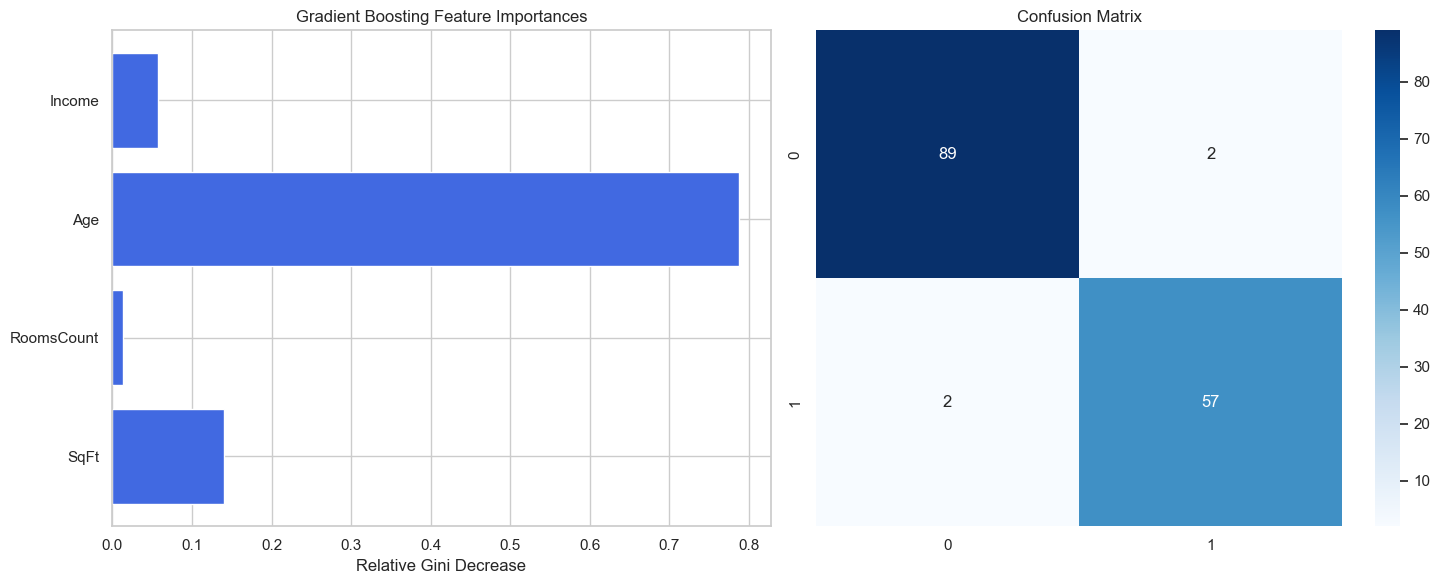

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# Plot 1: Feature Importances
importances = model.feature_importances_
axes[0].barh(X.columns, importances, color='royalblue')
axes[0].set_title("Gradient Boosting Feature Importances")
axes[0].set_xlabel("Relative Gini Decrease")

# Plot 2: Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

## 13. Save and Load Model

Serialize the model to disk via joblib.

In [11]:
joblib.dump(model, 'model.joblib')
loaded = joblib.load('model.joblib')
print('Loaded successfully!')

Loaded successfully!


## 14. Common Mistakes & Best Practices
- Forgetting to apply the fitted scaler to new evaluation data points, leading to prediction errors.
- Overfitting simple models with excessive features or polynomial terms.

## 15. Advantages
- Fast and easy to interpret baseline results.
- Requires minimal parameter tuning compared to deep neural networks.

## 16. Limitations
- Assumes linear or simple spatial patterns that do not always match real-world anomalies.
- Sensitive to noisy labels and extreme outliers.

## 17. Real-World Applications
- Predicting housing market price trends based on space features.
- Classifying credit card transactions as fraudulent vs benign.

## 18. Algorithm-Specific Interview Questions & Answers
**Q1: How does Gradient Boosting build trees?**

*A: Trees are fitted to the negative gradient (residuals) of the loss function. Each new tree corrects the residual errors of the existing ensemble.*

**Q2: What is the role of learning_rate (shrinkage)?**

*A: It scales the contribution of each tree. A lower learning rate (e.g. 0.01) requires more trees but reduces overfitting and improves generalization.*

**Q3: What is Gradient Boosting's primary weakness?**

*A: It is sequential (cannot be parallelized during training), making it slower to train than Random Forests.*



## 19. Algorithm-Specific Viva Voce Questions & Answers
**Q1: What are residuals?**

*A: The errors or differences between actual targets and predicted outputs.*

**Q2: What does the 'max_depth' parameter control?**

*A: Limits the depth of individual trees (weak learners), typically set to 3-6 to prevent overfitting.*

**Q3: Does it support custom loss functions?**

*A: Yes, Gradient Boosting can optimize any differentiable loss function.*



## 20. Practice Exercises
1. **Hyperparameter sweep**: Modify model parameters (such as `max_depth` or neighbor count `K`) and plot the test metric variance curve.
2. **Manual metric calculation**: Compute precision and recall scores manually from the confusion matrix values and verify results using scikit-learn.
3. **Outlier test**: Add an extreme value row to the dataset, re-train, and record the boundary displacement shift.

## 21. Conclusion

In this notebook, we implemented the complete modeling cycle: generating datasets, performing scaling, training the model, evaluating predictions with multiple metrics, saving outputs, and studying typical interview Q&A profiles.